# 12 回帰分析

### 計算内容とモデル
このセルでは回帰分析に必要なライブラリを読み込み、以降の推定で使う数値計算環境を準備します。線形回帰の基本モデルは
$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i$$
であり、最小二乗法では
$$\hat{\beta}=\arg\min_{\beta}\sum_{i=1}^{n}(y_i-\mathbf{x}_i^\top\beta)^2$$
を解きます。

### 計算内容とモデル
このセルではデータを読み込み、標本サイズ $n$ を定義します。回帰モデルは標本 $\{(x_i, y_i)\}_{i=1}^n$ に基づいて推定され、残差平方和
$$\mathrm{RSS}=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$
や誤差分散推定
$$\hat{\sigma}^2=\frac{\mathrm{RSS}}{n-p-1}$$
の計算に $n$ が使われます。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

%precision 3
%matplotlib inline

In [3]:
# statistical_analysis_with_python/data/ch12_scores_reg.csv
df = pd.read_csv('/home/jovyan/data/ch12_scores_reg.csv')
n = len(df)
df.head()

,小テスト,期末テスト,睡眠時間,通学方法
0,4.2,67,7.2,バス
1,7.2,71,7.9,自転車
2,0.0,19,5.3,バス
3,3.0,35,6.8,徒歩
4,1.5,35,7.5,徒歩


## 12.1 単回帰モデル

### 計算内容とモデル
このセルでは単回帰の説明変数 $x$ と目的変数 $y$ をベクトル化し、説明変数の数を $p=1$ と定義します。単回帰モデルは
$$y_i=\beta_0+\beta_1x_i+\varepsilon_i$$
で、行列表現では
$$\mathbf{y}=X\beta+\varepsilon$$
と書けます。

### 計算内容とモデル
このセルでは単回帰直線を推定し、散布図に当てはめ線を重ねて可視化します。推定する直線は
$$\hat{y}=\hat{\beta}_0+\hat{\beta}_1x$$
で、係数は
$$\min_{\beta_0,\beta_1}\sum_{i=1}^{n}(y_i-\beta_0-\beta_1x_i)^2$$
を最小にするように求めます。

In [4]:
x = np.array(df['小テスト'])
y = np.array(df['期末テスト'])
p = 1

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

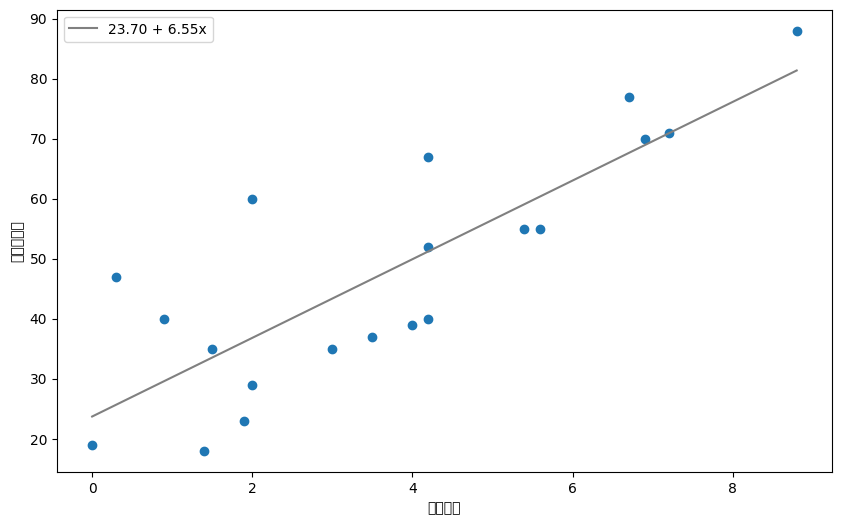

In [6]:
poly_fit = np.polyfit(x, y, 1)
poly_1d = np.poly1d(poly_fit)
xs = np.linspace(x.min(), x.max())
ys = poly_1d(xs)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.set_xlabel('小テスト')
ax.set_ylabel('期末テスト')
ax.plot(xs, ys, color='gray', label=f'{poly_fit[1]:.2f} + {poly_fit[0]:.2f}x')
ax.scatter(x, y)
ax.legend()

plt.show()

### 12.1.1 回帰分析における仮説

### 12.1.2 statsmodulesによる回帰分析

### 計算内容とモデル
このセルでは statsmodels の式指定を使って単回帰を推定します。推定モデルは
$$\mathrm{E}[Y\mid X]=\beta_0+\beta_1X$$
で、OLS 推定量は
$$\hat{\beta}=(X^\top X)^{-1}X^\top y$$
です。summary() では係数推定値、標準誤差、t 値、p 値、決定係数などを確認します。

In [7]:
formula = '期末テスト ~ 小テスト'
result = smf.ols(formula, data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     37.61
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           8.59e-06
Time:                        08:47:32   Log-Likelihood:                -76.325
No. Observations:                  20   AIC:                             156.7
Df Residuals:                      18   BIC:                             158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6995      4.714      5.028      0.000      13.796      33.603
小テスト           6.5537      1.069      6.133      0.000       4.309       8.799
==============================================================================
Omnibus:                        2.139   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.773
Skew:                           0.670   Prob(JB):                        0.412
Kurtosis:                       2.422   Cond. No.                         8.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 12.1.3 回帰係数

### 計算内容とモデル
このセルでは切片項を含む設計行列を構成します。単回帰の設計行列は
$$X=\begin{bmatrix}1&x_1\\ \vdots&\vdots\\ 1&x_n\end{bmatrix}$$
であり、回帰モデル
$$\mathbf{y}=X\beta+\varepsilon$$
を行列で表現する準備です。

In [8]:
X = np.array([np.ones_like(x), x]).T
X

array([[1. , 4.2],
       [1. , 7.2],
       [1. , 0. ],
       [1. , 3. ],
       [1. , 1.5],
       [1. , 0.9],
       [1. , 1.9],
       [1. , 3.5],
       [1. , 4. ],
       [1. , 5.4],
       [1. , 4.2],
       [1. , 6.9],
       [1. , 2. ],
       [1. , 8.8],
       [1. , 0.3],
       [1. , 6.7],
       [1. , 4.2],
       [1. , 5.6],
       [1. , 1.4],
       [1. , 2. ]])

### 計算内容とモデル
このセルでは最小二乗法で回帰係数を計算します。解く問題は
$$\hat{\beta}=\arg\min_{\beta}\|y-X\beta\|_2^2$$
であり、正規方程式
$$X^\top X\hat{\beta}=X^\top y$$
を満たす解として $\hat{\beta}_0, \hat{\beta}_1$ を求めます。

In [9]:
beta0_hat, beta1_hat = np.linalg.lstsq(X, y, rcond=None)[0]
beta0_hat, beta1_hat

(23.699, 6.554)

### 計算内容とモデル
このセルでは予測値と残差を計算します。予測値と残差は
$$\hat{y}_i=\hat{\beta}_0+\hat{\beta}_1x_i,\quad \hat{\varepsilon}_i=y_i-\hat{y}_i$$
で定義され、残差平方和
$$\mathrm{RSS}=\sum_{i=1}^{n}\hat{\varepsilon}_i^2$$
の基礎になります。

In [10]:
y_hat = beta0_hat + beta1_hat * x
eps_hat = y - y_hat

### 計算内容とモデル
このセルでは誤差分散を推定します。単回帰の不偏分散推定量は
$$\hat{\sigma}^2=\frac{\sum_{i=1}^{n}\hat{\varepsilon}_i^2}{n-p-1}$$
で、ここでは $p=1$ なので自由度は $n-2$ です。NumPy の不偏分散計算でも同じ考え方を使っています。

In [11]:
s_var = np.var(eps_hat, ddof = p + 1)
s_var

134.290

### 計算内容とモデル
このセルでは $(X^\top X)^{-1}$ の対角成分を取り出します。回帰係数ベクトルの分散共分散行列は
$$\mathrm{Var}(\hat{\beta})=\hat{\sigma}^2 (X^\top X)^{-1}$$
なので、対角成分 $C_0, C_1$ は各係数の標準誤差計算に使われます。

In [12]:
C0, C1 = np.diag(np.linalg.pinv(np.dot(X.T, X)))

### 計算内容とモデル
このセルでは切片と傾きの標準誤差を計算します。各係数の標準誤差は
$$\mathrm{SE}(\hat{\beta}_j)=\sqrt{\hat{\sigma}^2 C_j}$$
で与えられ、信頼区間や仮説検定で使う基礎量になります。

In [13]:
np.sqrt(s_var * C0), np.sqrt(s_var * C1)

(4.714, 1.069)

### 計算内容とモデル
このセルでは切片 $\beta_0$ の95%信頼区間を計算します。自由度 $n-2$ の t 分布を用いて
$$\hat{\beta}_0 \pm t_{0.975,\,n-2}\,\mathrm{SE}(\hat{\beta}_0)$$
で区間推定を行います。

In [14]:
rv = stats.t(n - 2)

lcl = beta0_hat - rv.isf(0.025) * np.sqrt(s_var * C0)
ucl = beta0_hat - rv.isf(0.975) * np.sqrt(s_var * C0)
lcl, ucl

(13.796, 33.603)

### 計算内容とモデル
このセルでは傾き $\beta_1$ の95%信頼区間を計算します。区間は
$$\hat{\beta}_1 \pm t_{0.975,\,n-2}\,\mathrm{SE}(\hat{\beta}_1)$$
で与えられ、説明変数の効果の不確実性を評価します。

In [16]:
rv = stats.t(n - 2)

lcl = beta1_hat - rv.isf(0.025) * np.sqrt(s_var * C1)
ucl = beta1_hat - rv.isf(0.975) * np.sqrt(s_var * C1)
lcl, ucl

(4.309, 8.799)

### 計算内容とモデル
このセルでは傾き係数の t 統計量を計算します。帰無仮説 $H_0:\beta_1=0$ に対して
$$t=\frac{\hat{\beta}_1}{\mathrm{SE}(\hat{\beta}_1)}$$
を求め、説明変数が有意に効いているかを評価します。

In [18]:
t = beta1_hat / np.sqrt(s_var * C1)
t

6.133

### 計算内容とモデル
このセルでは t 統計量から両側 p 値を計算します。p 値は
$$p\text{-value}=2\{1-F_t(|t|;\nu)\}$$
で与えられ、ここで $F_t$ は自由度 $\nu=n-2$ の t 分布の累積分布関数です。

In [19]:
(1 - rv.cdf(t)) * 2

0.000

### 計算内容とモデル
このセルでは切片 $\beta_0$ の t 統計量を計算します。帰無仮説 $H_0:\beta_0=0$ に対し
$$t=\frac{\hat{\beta}_0}{\mathrm{SE}(\hat{\beta}_0)}$$
を用いて、切片が 0 から有意にずれているかを評価します。

In [20]:
t = beta0_hat / np.sqrt(s_var * C0)
t

5.028

### 計算内容とモデル
このセルでは切片の t 統計量に対応する両側 p 値を計算します。計算式は
$$p\text{-value}=2\{1-F_t(|t|;\nu)\}$$
で、自由度は $\nu=n-2$ です。

In [21]:
(1 - rv.cdf(t)) * 2

0.000

## 12.2 重回帰モデル

### 計算内容とモデル
このセルでは重回帰モデルを推定します。モデルは
$$y_i=\beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\varepsilon_i$$
で、OLS 推定量
$$\hat{\beta}=(X^\top X)^{-1}X^\top y$$
により、他の変数を固定したときの偏回帰係数を評価します。

In [24]:
formula = '期末テスト ~ 小テスト + 睡眠時間'
result = smf.ols(formula, data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     26.35
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           6.19e-06
Time:                        09:04:03   Log-Likelihood:                -73.497
No. Observations:                  20   AIC:                             153.0
Df Residuals:                      17   BIC:                             156.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8709     11.635     -0.161      0.874     -26.420      22.678
小テスト           6.4289      0.956      6.725      0.000       4.412       8.446
睡眠時間           4.1917      1.778      2.357      0.031       0.440       7.943
==============================================================================
Omnibus:                        2.073   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.355   Jarque-Bera (JB):                1.716
Skew:                           0.660   Prob(JB):                        0.424
Kurtosis:                       2.437   Cond. No.                         38.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 12.2.1 回帰計数

### 計算内容とモデル
このセルでは重回帰の説明変数 $x_1, x_2$ と目的変数 $y$ を準備し、説明変数数を $p=2$ と定義します。モデルは
$$\mathbf{y}=X\beta+\varepsilon,\quad \beta=(\beta_0,\beta_1,\beta_2)^\top$$
です。

In [25]:
x1 = df['小テスト']
x2 = df['睡眠時間']
y = df['期末テスト']
p = 2

### 計算内容とモデル
このセルでは重回帰の設計行列を作り、係数を最小二乗法で推定します。推定量は
$$\hat{\beta}=(X^\top X)^{-1}X^\top y$$
で、$\hat{\beta}_1, \hat{\beta}_2$ はそれぞれ小テストと睡眠時間の偏回帰係数です。

In [26]:
X = np.array([np.ones_like(x1), x1, x2]).T
beta0_hat, beta1_hat, beta2_hat = np.linalg.lstsq(X, y, rcond=None)[0]
beta0_hat, beta1_hat, beta2_hat

(-1.871, 6.429, 4.192)

### 計算内容とモデル
このセルでは重回帰の予測値と残差を計算します。予測値と残差は
$$\hat{y}_i=\hat{\beta}_0+\hat{\beta}_1x_{1i}+\hat{\beta}_2x_{2i},\quad \hat{\varepsilon}_i=y_i-\hat{y}_i$$
で定義されます。

In [27]:
y_hat = beta0_hat + beta1_hat * x1 + beta2_hat * x2
eps_hat = y - y_hat

### 計算内容とモデル
このセルでは重回帰の誤差分散と係数分散の基礎量を計算します。誤差分散推定量は
$$\hat{\sigma}^2=\frac{\sum_{i=1}^{n}\hat{\varepsilon}_i^2}{n-p-1}$$
であり、係数分散は
$$\mathrm{Var}(\hat{\beta})=\hat{\sigma}^2 (X^\top X)^{-1}$$
です。

In [28]:
s_var = np.sum(eps_hat ** 2) / (n - p - 1)
C0, C1, C2 = np.diag(np.linalg.pinv(np.dot(X.T, X)))

### 計算内容とモデル
このセルでは睡眠時間の係数 $\beta_2$ の95%信頼区間を計算します。区間は
$$\hat{\beta}_2 \pm t_{0.975,\,n-p-1}\,\mathrm{SE}(\hat{\beta}_2)$$
で与えられ、他の説明変数を固定した条件での効果を評価します。

In [29]:
rv = stats.t(n - p - 1)
lcl = beta2_hat - rv.isf(0.025) * np.sqrt(s_var * C2)
hcl = beta2_hat - rv.isf(0.975) * np.sqrt(s_var * C2)
lcl, hcl

(0.440, 7.943)

### 12.2.2 ダミー変数

### 計算内容とモデル
このセルではカテゴリ変数を含むダミー変数回帰を推定します。基準カテゴリを除いたダミー変数 $D_j$ を使うと
$$y_i=\beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\gamma_1D_{1i}+\cdots+\varepsilon_i$$
のように表され、カテゴリ間の平均差を係数で表現できます。

In [30]:
formula = '期末テスト ~ 小テスト + 睡眠時間 + 通学方法'
result = smf.ols(formula, data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     13.46
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           7.47e-05
Time:                        09:08:54   Log-Likelihood:                -72.368
No. Observations:                  20   AIC:                             154.7
Df Residuals:                      15   BIC:                             159.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.4788     12.068     -0.040      0.969     -26.202      25.244
通学方法[T.徒歩]     -5.8437      5.447     -1.073      0.300     -17.453       5.766
通学方法[T.自転車]     1.8118      6.324      0.286      0.778     -11.668      15.292
小テスト            6.0029      1.033      5.809      0.000       3.800       8.206
睡眠時間            4.5238      1.809      2.501      0.024       0.668       8.380
==============================================================================
Omnibus:                        1.764   Durbin-Watson:                   1.418
Prob(Omnibus):                  0.414   Jarque-Bera (JB):                0.989
Skew:                           0.545   Prob(JB):                        0.610
Kurtosis:                       2.985   Cond. No.                         39.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 12.3 モデルの選択

### 計算内容とモデル
このセルでは単回帰モデルを再推定し、モデル選択指標の計算に必要な fitted values や残差を準備します。モデルは
$$y_i=\beta_0+\beta_1x_i+\varepsilon_i$$
で、以降の決定係数や尤度計算はこの推定結果に基づきます。

In [31]:
x = np.array(df['小テスト'])
y = np.array(df['期末テスト'])
p = 1

result = smf.ols('期末テスト ~ 小テスト', data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     37.61
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           8.59e-06
Time:                        09:11:37   Log-Likelihood:                -76.325
No. Observations:                  20   AIC:                             156.7
Df Residuals:                      18   BIC:                             158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6995      4.714      5.028      0.000      13.796      33.603
小テスト           6.5537      1.069      6.133      0.000       4.309       8.799
==============================================================================
Omnibus:                        2.139   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.773
Skew:                           0.670   Prob(JB):                        0.412
Kurtosis:                       2.422   Cond. No.                         8.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 計算内容とモデル
このセルでは当てはめ値を取り出します。当てはめ値は
$$\hat{y}=X\hat{\beta}$$
で与えられ、決定係数
$$R^2=\frac{\sum_{i=1}^{n}(\hat{y}_i-\bar{y})^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$
の計算に使います。

In [32]:
y_hat = np.array(result.fittedvalues)
y_hat

array([51.225, 70.886, 23.699, 43.361, 33.53 , 29.598, 36.152, 46.638,
       49.914, 59.09 , 51.225, 68.92 , 36.807, 81.372, 25.666, 67.61 ,
       51.225, 60.4  , 32.875, 36.807])

### 計算内容とモデル
このセルでは残差を取り出します。残差は
$$\hat{\varepsilon}_i=y_i-\hat{y}_i$$
で定義され、残差平方和
$$\mathrm{RSS}=\sum_{i=1}^{n}\hat{\varepsilon}_i^2$$
やモデル診断に使われます。

In [33]:
eps_hat = np.array(result.resid)
eps_hat

array([ 15.775,   0.114,  -4.699,  -8.361,   1.47 ,  10.402, -13.152,
        -9.638, -10.914,  -4.09 , -11.225,   1.08 ,  -7.807,   6.628,
        21.334,   9.39 ,   0.775,  -5.4  , -14.875,  23.193])

### 計算内容とモデル
このセルでは残差平方和を計算します。残差平方和は
$$\mathrm{RSS}=\sum_{i=1}^{n}\hat{\varepsilon}_i^2$$
で、未説明変動の大きさを表す基本量です。

In [34]:
np.sum(eps_hat ** 2)

2417.228

### 12.3.1 決定係数

### 計算内容とモデル
このセルでは全変動、説明変動、未説明変動を計算します。分散分解は
$$\mathrm{TSS}=\sum (y_i-\bar{y})^2,\quad \mathrm{ESS}=\sum (\hat{y}_i-\bar{y})^2,\quad \mathrm{RSS}=\sum (y_i-\hat{y}_i)^2$$
で表され、線形回帰では
$$\mathrm{TSS}=\mathrm{ESS}+\mathrm{RSS}$$
が成り立ちます。

In [35]:
total_var = np.sum((y - np.mean(y)) ** 2)
exp_var = np.sum((y_hat - np.mean(y)) ** 2)
unexp_var = np.sum(eps_hat ** 2)

### 計算内容とモデル
このセルでは分散分解の等式を数値で確認します。理論上は
$$\sum_{i=1}^{n}(y_i-\bar{y})^2=\sum_{i=1}^{n}(\hat{y}_i-\bar{y})^2+\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$
が成り立ちます。

In [36]:
total_var, exp_var + unexp_var

(7468.550, 7468.550)

### 計算内容とモデル
このセルでは決定係数 $R^2$ を計算します。定義は
$$R^2=\frac{\mathrm{ESS}}{\mathrm{TSS}}=1-\frac{\mathrm{RSS}}{\mathrm{TSS}}$$
で、目的変数の変動をモデルがどれだけ説明したかを表します。

In [37]:
exp_var / total_var

0.676

### 計算内容とモデル
このセルでは単回帰で成り立つ $R^2$ と相関係数の関係を確認します。単回帰では
$$R^2=r_{xy}^2$$
が成り立ち、ここで
$$r_{xy}=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum (x_i-\bar{x})^2\sum (y_i-\bar{y})^2}}$$
です。

In [38]:
np.corrcoef(x, y)[0, 1] ** 2

0.676

### 12.3.2 自由度調整済み決定係数

### 計算内容とモデル
このセルでは自由度調整済み決定係数を計算します。式は
$$\bar{R}^2=1-\frac{\mathrm{RSS}/(n-p-1)}{\mathrm{TSS}/(n-1)}$$
で、説明変数の数が増えたときの過剰適合を補正します。

In [39]:
1 - (unexp_var / (n - p - 1)) / (total_var / (n - 1))

0.658

### 12.3.3 F検定

### 計算内容とモデル
このセルでは回帰式全体の有意性を調べる F 統計量を計算します。帰無仮説 $H_0:\beta_1=\cdots=\beta_p=0$ に対し
$$F=\frac{\mathrm{ESS}/p}{\mathrm{RSS}/(n-p-1)}$$
を用います。

In [40]:
f = (exp_var / p) / (unexp_var / (n - p - 1))
f

37.615

### 計算内容とモデル
このセルでは F 統計量の p 値を計算します。F 分布の累積分布関数 $F_F$ を使って
$$p\text{-value}=1-F_F(f;\,p,n-p-1)$$
を求め、回帰式全体の有意性を判断します。

In [41]:
rv = stats.f(p, n - p - 1)
1 - rv.cdf(f)

0.000

### 12.3.4 最大対数尤度とAIC

### 計算内容とモデル
このセルではベルヌーイ試行列の尤度を計算します。観測 $x_i\in\{0,1\}$ に対する尤度は
$$L(p)=\prod_{i=1}^{n}p^{x_i}(1-p)^{1-x_i}$$
で、パラメータ $p$ のもっともらしさを表します。

In [42]:
prob = 0.3
coin_result = [0, 1, 0, 0, 1]

rv = stats.bernoulli(prob)
L = np.prod(rv.pmf(coin_result))
L

0.031

### 計算内容とモデル
このセルでは尤度関数を $p\in[0,1]$ の範囲で可視化します。尤度関数
$$L(p)=\prod_{i=1}^{n}p^{x_i}(1-p)^{1-x_i}$$
の形を見ることで、最尤推定値 $\hat{p}$ がどの付近にあるかを直感的に確認できます。

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23588 (\N{CJK UNIFIED IDEOGRAPH-5C24}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


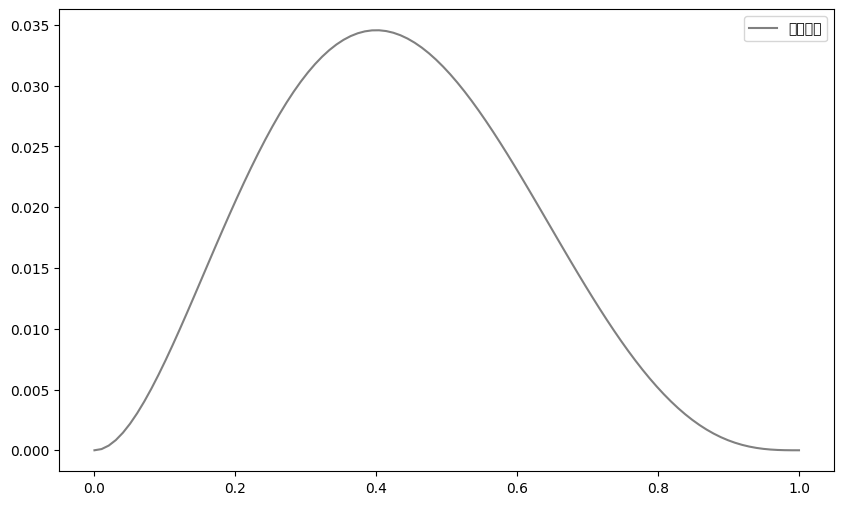

In [45]:
ps = np.linspace(0, 1, 100)
Ls = [np.prod(stats.bernoulli(prob).pmf(coin_result)) for prob in ps]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(ps, Ls, label='尤度関数', color='gray')
ax.legend()
plt.show()

### 計算内容とモデル
このセルでは対数尤度を計算します。対数尤度は
$$\ell(\theta)=\log L(\theta)=\sum_{i=1}^{n}\log f(x_i\mid\theta)$$
で定義され、積を和に変えることで数値計算を安定させます。

In [46]:
prob = 0.4
rv = stats.bernoulli(prob)
mll = np.sum(np.log(rv.pmf([0, 1, 0, 0, 1])))
mll

-3.365

### 計算内容とモデル
このセルでは正規誤差を仮定した回帰モデルの対数尤度を計算します。仮定
$$y_i\sim \mathcal{N}(\hat{y}_i,\sigma^2)$$
の下で
$$\ell=\sum_{i=1}^{n}\log \phi(y_i;\hat{y}_i,\sigma^2)$$
を求め、情報量基準の準備をします。

In [47]:
rv = stats.norm(y_hat, np.sqrt(unexp_var / n))
mll = np.sum(np.log(rv.pdf(y)))
mll

-76.325

### 計算内容とモデル
このセルでは AIC を計算します。AIC は
$$\mathrm{AIC}=-2\ell(\hat{\theta})+2k$$
で定義され、$k=p+1$ を推定パラメータ数としてモデルの当てはまりと複雑さのバランスを評価します。

In [48]:
aic = -2 * mll + 2 * (p + 1)
aic

156.650

### 計算内容とモデル
このセルでは BIC を計算します。BIC は
$$\mathrm{BIC}=-2\ell(\hat{\theta})+k\log n$$
で定義され、AIC より複雑なモデルへの罰則が強い情報量基準です。

In [49]:
bic = -2 * mll + np.log(n) * (p + 1)
bic

158.642

### 12.4 モデルの妥当性

### 計算内容とモデル
このセルでは残差診断のために重回帰モデルを再推定します。モデルは
$$y_i=\beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\varepsilon_i$$
で、以降の正規性・自己相関・多重共線性の診断はこの推定結果の残差に基づいて行います。

In [50]:
formula = '期末テスト ~ 小テスト + 睡眠時間'
result = smf.ols(formula, data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     26.35
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           6.19e-06
Time:                        09:27:06   Log-Likelihood:                -73.497
No. Observations:                  20   AIC:                             153.0
Df Residuals:                      17   BIC:                             156.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8709     11.635     -0.161      0.874     -26.420      22.678
小テスト           6.4289      0.956      6.725      0.000       4.412       8.446
睡眠時間           4.1917      1.778      2.357      0.031       0.440       7.943
==============================================================================
Omnibus:                        2.073   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.355   Jarque-Bera (JB):                1.716
Skew:                           0.660   Prob(JB):                        0.424
Kurtosis:                       2.437   Cond. No.                         38.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 計算内容とモデル
このセルでは残差を取り出し、モデル診断の対象データを準備します。残差は
$$\hat{\varepsilon}_i=y_i-\hat{y}_i$$
で、正規性や自己相関の仮定を確認する基礎になります。

In [51]:
eps_hat = np.array(result.resid)

### 12.4.1 正規性の検定

### 計算内容とモデル
このセルでは残差の歪度を計算して正規性を診断します。歪度は
$$\mathrm{Skew}(\varepsilon)=\frac{\mathrm{E}[(\varepsilon-\mu)^3]}{\sigma^3}$$
で、0 に近いほど分布が左右対称です。

In [52]:
stats.skew(eps_hat)

0.660

### 計算内容とモデル
このセルでは残差の尖度を計算して正規性を診断します。尖度は
$$\mathrm{Kurt}(\varepsilon)=\frac{\mathrm{E}[(\varepsilon-\mu)^4]}{\sigma^4}$$
で、Pearson の定義では正規分布は 3 です。

In [53]:
stats.kurtosis(eps_hat, fisher=False)

2.437

### 12.4.2 ダービン・ワトソン比

### 計算内容とモデル
このセルではダービン・ワトソン比を計算し、残差の自己相関を診断します。定義は
$$DW=\frac{\sum_{t=2}^{n}(e_t-e_{t-1})^2}{\sum_{t=1}^{n}e_t^2}$$
で、$DW\approx 2$ なら自己相関が弱いと解釈します。

In [54]:
np.sum(np.diff(eps_hat) ** 2) / np.sum(eps_hat ** 2)

1.508

### 12.4.3 多重共線性

### 計算内容とモデル
このセルでは小テストの完全線形変換として新しい説明変数を作り、多重共線性の例を構成します。
$$x_{\mathrm{mid}}=2x_{\mathrm{small}}$$
のように強い線形従属があると、設計行列 $X$ の列がほぼ重なり
$$X^\top X$$
が特異に近くなります。

In [55]:
df['中テスト'] = df['小テスト'] * 2
df.head()

,小テスト,期末テスト,睡眠時間,通学方法,中テスト
0,4.2,67,7.2,バス,8.4
1,7.2,71,7.9,自転車,14.4
2,0.0,19,5.3,バス,0.0
3,3.0,35,6.8,徒歩,6.0
4,1.5,35,7.5,徒歩,3.0


### 計算内容とモデル
このセルでは共線性の高い2変数を同時に入れた重回帰を推定します。モデルは
$$y_i=\beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\varepsilon_i$$
ですが、$x_2\approx c x_1$ だと
$$(X^\top X)^{-1}$$
が不安定になり、標準誤差の増大や係数推定の不安定化が起こります。

In [56]:
formula = '期末テスト ~ 小テスト + 中テスト'
result = smf.ols(formula, data=df).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  期末テスト   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     37.61
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           8.59e-06
Time:                        09:31:53   Log-Likelihood:                -76.325
No. Observations:                  20   AIC:                             156.7
Df Residuals:                      18   BIC:                             158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6995      4.714      5.028      0.000      13.796      33.603
小テスト           1.3107      0.214      6.133      0.000       0.862       1.760
中テスト           2.6215      0.427      6.133      0.000       1.723       3.519
==============================================================================
Omnibus:                        2.139   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.773
Skew:                           0.670   Prob(JB):                        0.412
Kurtosis:                       2.422   Cond. No.                     1.04e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.8e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""